In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
print("Upload an image with at least one human face (jpg, png):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Upload an image with at least one human face (jpg, png):


Saving faces.jpeg to faces (1).jpeg


In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
'haarcascade_frontalface_default.xml')

In [ ]:
# Step 3: Read and convert the image to grayscale
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

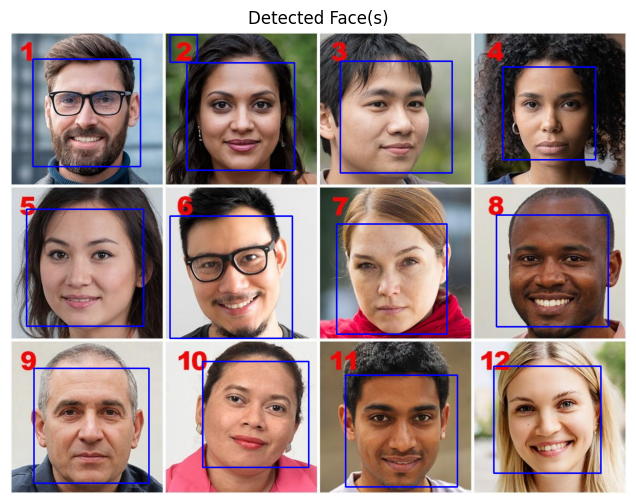

In [ ]:
# Step 4: Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
# Step 5: Draw rectangles around detected faces
for (x, y, w, h) in faces:
  cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Step 6: Display the result using matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Detected Face(s)")
plt.axis('off')
plt.show()

In [ ]:
#Code Example 2: Real-Time Face Detection with Webcam


In [ ]:
# Step 1: Upload a short video with a human face
print("Upload a video file (e.g., .mp4, .avi):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

Upload a video file (e.g., .mp4, .avi):


Saving rd4k230-00039-uop1bv3szn__313cf94fbf79a2b8879ffd5a252f0b0f__P360.mp4 to rd4k230-00039-uop1bv3szn__313cf94fbf79a2b8879ffd5a252f0b0f__P360 (1).mp4


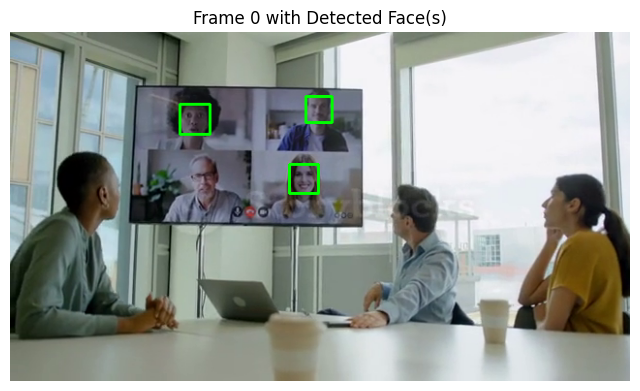

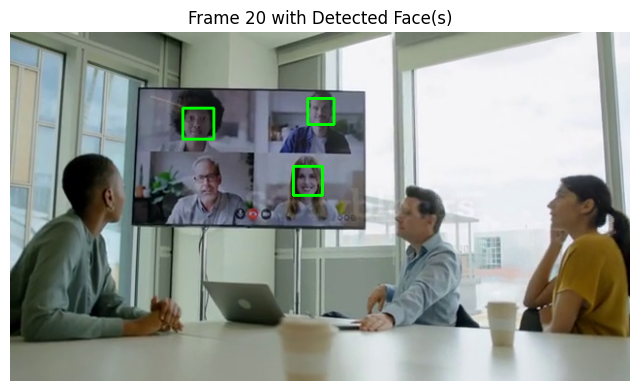

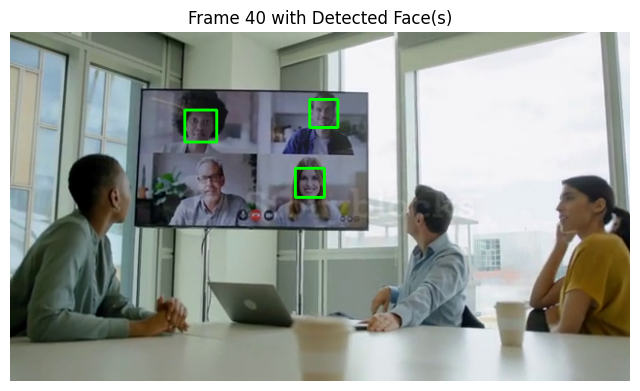

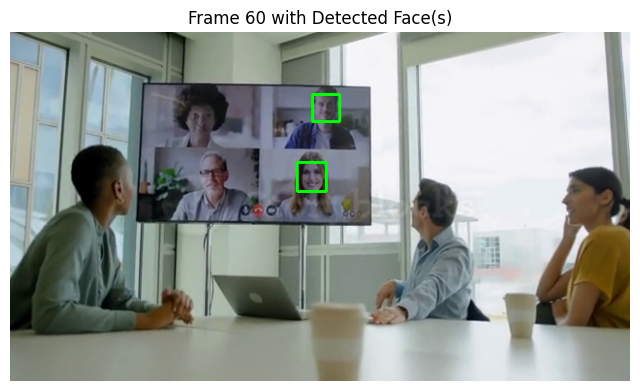

In [ ]:
# Step 2: Load the Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
'haarcascade_frontalface_default.xml')

frame_count = 0
while True:
  ret, frame = cap.read()
  if not ret or frame_count >= 100: # limit to 100 frames to avoid long runtime
    break

  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.1, 4)

  for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

  # Convert BGR to RGB for matplotlib
  rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

  # Display every 20th frame
  if frame_count % 20 == 0:
    plt.figure(figsize=(8, 5))
    plt.imshow(rgb)
    plt.title(f"Frame {frame_count} with Detected Face(s)")
    plt.axis('off')
    plt.show()

  frame_count += 1 # Increment frame_count inside the loop

In [ ]:
#Case Study 1: Automated Celebrity Face Recognition for Media Archiving

In [ ]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Check if image loaded successfully and has valid dimensions
                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
                else:
                    print(f"Failed to load or invalid image: {img_path}") # Print an error message for debugging
            current_label += 1

    return images, labels, label_dict

# --- Training Phase ---
dataset_path = '/content/face_recognition_dataset/Faces' # Changed to the full path
images, labels, label_dict = load_dataset(dataset_path)

# Create and train the LBPH face recognizer
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))

# Save the trained model
recognizer.save('face_recognizer.yml')

# Save label map to file
with open("label_map.txt", "w") as f: # Create and open the label map file in write mode ('w')
    for label, name in label_dict.items():
        f.write(f"{label}:{name}\n") # Write each label and name to the file

# --- Recognition Phase ---
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("/content/face_recognizer.yml")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load label map
label_map = {}
with open("label_map.txt", "r") as f:
    for line in f:
        label, name = line.strip().split(":")
        label_map[int(label)] = name

# Load captured image and process
img_path = r"C:\Users\haroo\Desktop\cv lab\6\thumb.jpg"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    label, confidence = recognizer.predict(roi_gray)
    name = label_map.get(label, "Unknown")

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, f"{name} ({int(confidence)})", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Show the result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/face_recognition_dataset/Faces'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/archive (7) (1).zip" -d "/content/dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/archive (7) (1).zip
replace /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_0.jpg  
replace /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_1.jpg  
  inflating: /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_10.jpg  
  inflating: /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_11.jpg  
  inflating: /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_12.jpg  
  inflating: /content/dataset/Dataset/Faces/Akshay Kumar/Akshay Kumar_13.j

In [ ]:
y